# ASL Model Comparison

Reads training results from the cluster and compares **all** models:
- Scratch CNNs: baseline, deep_cnn, regularisation variants
- Transfer learning: ResNet-18/50, MobileNetV3-Small, EfficientNet-B0


> `test_results.json` and `y_true/y_pred.npy` are only present when trained via `train.py` (SLURM jobs).  
> If absent, the notebook falls back to best-validation metrics from `history.json`.

In [7]:
import json
import pathlib
import warnings

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("husl")

## Configuration
Set `RESULTS_ROOT` to the local folder where you downloaded the cluster results.

In [ ]:
RESULTS_ROOT = pathlib.Path("../results")
FIGURES_DIR  = pathlib.Path("../results/comparison")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = [
    "0","1","2","3","4","5","6","7","8","9",
    "A","B","C","D","E","F","G","H","I","J","K","L","M",
    "N","O","P","Q","R","S","T","U","V","W","X","Y","Z","nothing",
]

# (display_name, exp_dir, phase1_dir, approx_params_M)
# phase1_dir is only used for transfer models (combined curve)
# approx_params_M: fill in from notebook output / known architecture sizes
MODELS = [
    # Scratch CNNs
    ("Baseline CNN", "baseline", None, 0.155),
    ("Deep CNN", "deep_cnn", None, None),
    ("Deep + Dropout", "deep_dropout", None, None),
    ("Deep + BN", "deep_batchnorm", None, None),
    ("Deep + BN + Dropout",  "deep_bn_dropout", None, None),
    ("Deep + BN + Drop + Aug","deep_bn_dropout_aug", None, None),
    # Transfer learning
    ("ResNet-18", "transfer_resnet18", "transfer_resnet18_phase1", 11.18),
    ("ResNet-50", "transfer_resnet50", "transfer_resnet50_phase1", 25.56),
    ("MobileNetV3-Small", "transfer_mobilenet_v3_small", "transfer_mobilenet_v3_small_phase1", 2.54),
    ("EfficientNet-B0", "transfer_efficientnet_b0", "transfer_efficientnet_b0_phase1", 5.29),
]

# Groups for colour coding
SCRATCH_NAMES = [m[1] for m in MODELS if m[2] is None]
TRANSFER_NAMES = [m[1] for m in MODELS if m[2] is not None]

## Load Results

In [9]:
def _load_json(path):
    if path and pathlib.Path(path).exists():
        with open(path) as f:
            return json.load(f)
    return None


def load_model_data(display_name, exp_dir, phase1_dir, params_m):
    result = {
        "display_name": display_name,
        "exp_dir":      exp_dir,
        "params_M":     params_m,
        "is_transfer":  phase1_dir is not None,
    }

    base = RESULTS_ROOT / exp_dir
    if not base.exists():
        result["missing"] = True
        return result
    result["missing"] = False

    # Training history — phase 2 (or only phase for scratch models)
    hist = _load_json(base / "history.json")
    result["history"] = hist

    # Phase-1 history (transfer only)
    if phase1_dir:
        result["phase1_history"] = _load_json(RESULTS_ROOT / phase1_dir / "history.json")

    # Test results (only present when trained via train.py / SLURM)
    test_res = _load_json(base / "test_results.json")
    result["test_results"] = test_res

    # Raw predictions (SLURM runs)
    for arr in ("y_true", "y_pred"):
        p = base / f"{arr}.npy"
        result[arr] = np.load(str(p)) if p.exists() else None

    # Confusion-matrix image (notebooks save cm.png, train.py saves confusion_matrix.png)
    for cm_name in ("cm.png", "confusion_matrix.png"):
        cm_path = base / cm_name
        if cm_path.exists():
            result["cm_path"] = str(cm_path)
            break

    return result


all_results = [load_model_data(*m) for m in MODELS]
available   = [r for r in all_results if not r.get("missing")]

print(f"Found {len(available)}/{len(MODELS)} experiment directories\n")
for r in all_results:
    tag = "OK" if not r.get("missing") else "MISSING"
    has_test  = "test_results.json" if r.get("test_results") else "val-only"
    has_npy   = "npy" if r.get("y_true") is not None else "no-npy"
    print(f"  [{tag:7s}] {r['display_name']:30s}  {has_test:18s}  {has_npy}")

Found 9/10 experiment directories

  [OK     ] Baseline CNN                    val-only            no-npy
  [OK     ] Deep CNN                        val-only            no-npy
  [OK     ] Deep + Dropout                  test_results.json   npy
  [MISSING] Deep + BN                       val-only            no-npy
  [OK     ] Deep + BN + Dropout             test_results.json   npy
  [OK     ] Deep + BN + Drop + Aug          test_results.json   npy
  [OK     ] ResNet-18                       test_results.json   npy
  [OK     ] ResNet-50                       test_results.json   npy
  [OK     ] MobileNetV3-Small               test_results.json   npy
  [OK     ] EfficientNet-B0                 test_results.json   npy


## Summary Metrics Table

In [10]:
def best_val_f1(r):
    h = r.get("history")
    if h and "val_macro_f1" in h:
        return max(h["val_macro_f1"])
    return float("nan")


def total_train_time_h(r):
    """Sum epoch times across both phases (hours)."""
    secs = 0.0
    for key in ("phase1_history", "history"):
        h = r.get(key)
        if h and "epoch_time_s" in h:
            secs += sum(h["epoch_time_s"])
    return secs / 3600 if secs > 0 else float("nan")


rows = []
for r in all_results:
    tr = r.get("test_results") or {}
    row = {
        "Model":          r["display_name"],
        "Type":           "Transfer" if r["is_transfer"] else "Scratch CNN",
        "Params (M)":     r["params_M"],
        "Val F1 (best)":  best_val_f1(r) if not r.get("missing") else float("nan"),
        "Test F1":        tr.get("test_macro_f1", float("nan")),
        "Test Acc":       tr.get("test_acc",       float("nan")),
        "Bal Acc":        tr.get("test_balanced_acc", float("nan")),
        "Latency (ms)":   tr.get("inference_latency_ms", float("nan")),
        "Train Time (h)": total_train_time_h(r) if not r.get("missing") else float("nan"),
    }
    rows.append(row)

df = pd.DataFrame(rows)

# Use Test F1 if available, otherwise best Val F1
df["Best F1"] = df.apply(
    lambda x: x["Test F1"] if not np.isnan(x["Test F1"]) else x["Val F1 (best)"],
    axis=1,
)
df_sorted = df.sort_values("Best F1", ascending=False).reset_index(drop=True)

# Pretty-print
def fmt(v, spec):
    return spec.format(v) if not (isinstance(v, float) and np.isnan(v)) else "—"

display_df = pd.DataFrame({
    "Model":         df_sorted["Model"],
    "Type":          df_sorted["Type"],
    "Params (M)":    df_sorted["Params (M)"].apply(lambda v: fmt(v, "{:.2f}")),
    "Val F1 (best)": df_sorted["Val F1 (best)"].apply(lambda v: fmt(v, "{:.4f}")),
    "Test F1":       df_sorted["Test F1"].apply(lambda v: fmt(v, "{:.4f}")),
    "Test Acc":      df_sorted["Test Acc"].apply(lambda v: fmt(v, "{:.4f}")),
    "Bal Acc":       df_sorted["Bal Acc"].apply(lambda v: fmt(v, "{:.4f}")),
    "Latency (ms)":  df_sorted["Latency (ms)"].apply(lambda v: fmt(v, "{:.2f}")),
    "Train Time (h)": df_sorted["Train Time (h)"].apply(lambda v: fmt(v, "{:.1f}")),
})
display_df.index = range(1, len(display_df) + 1)
display_df

,Model,Type,Params (M),Val F1 (best),Test F1,Test Acc,Bal Acc,Latency (ms),Train Time (h)
1,ResNet-50,Transfer,25.56,0.9763,0.9755,0.9939,0.9974,2.50,0.3
2,ResNet-18,Transfer,11.18,0.9805,0.9595,0.9914,0.9724,1.01,0.3
3,MobileNetV3-Small,Transfer,2.54,0.9683,0.9575,0.9898,0.9831,2.06,0.4
4,EfficientNet-B0,Transfer,5.29,0.9694,0.9528,0.9899,0.9776,3.24,0.4
5,Deep + BN + Dropout,Scratch CNN,—,0.7014,0.7104,0.7352,0.8189,0.36,1.0
6,Deep CNN,Scratch CNN,—,0.6818,—,—,—,—,0.6
7,Deep + BN + Drop + Aug,Scratch CNN,—,0.6394,0.6534,0.6816,0.7855,0.35,1.0
8,Baseline CNN,Scratch CNN,0.15,0.6465,—,—,—,—,0.2
9,Deep + Dropout,Scratch CNN,—,0.6313,0.6438,0.6791,0.7553,0.28,0.6
10,Deep + BN,Scratch CNN,—,—,—,—,—,—,—


## Metrics Comparison - Bar Charts

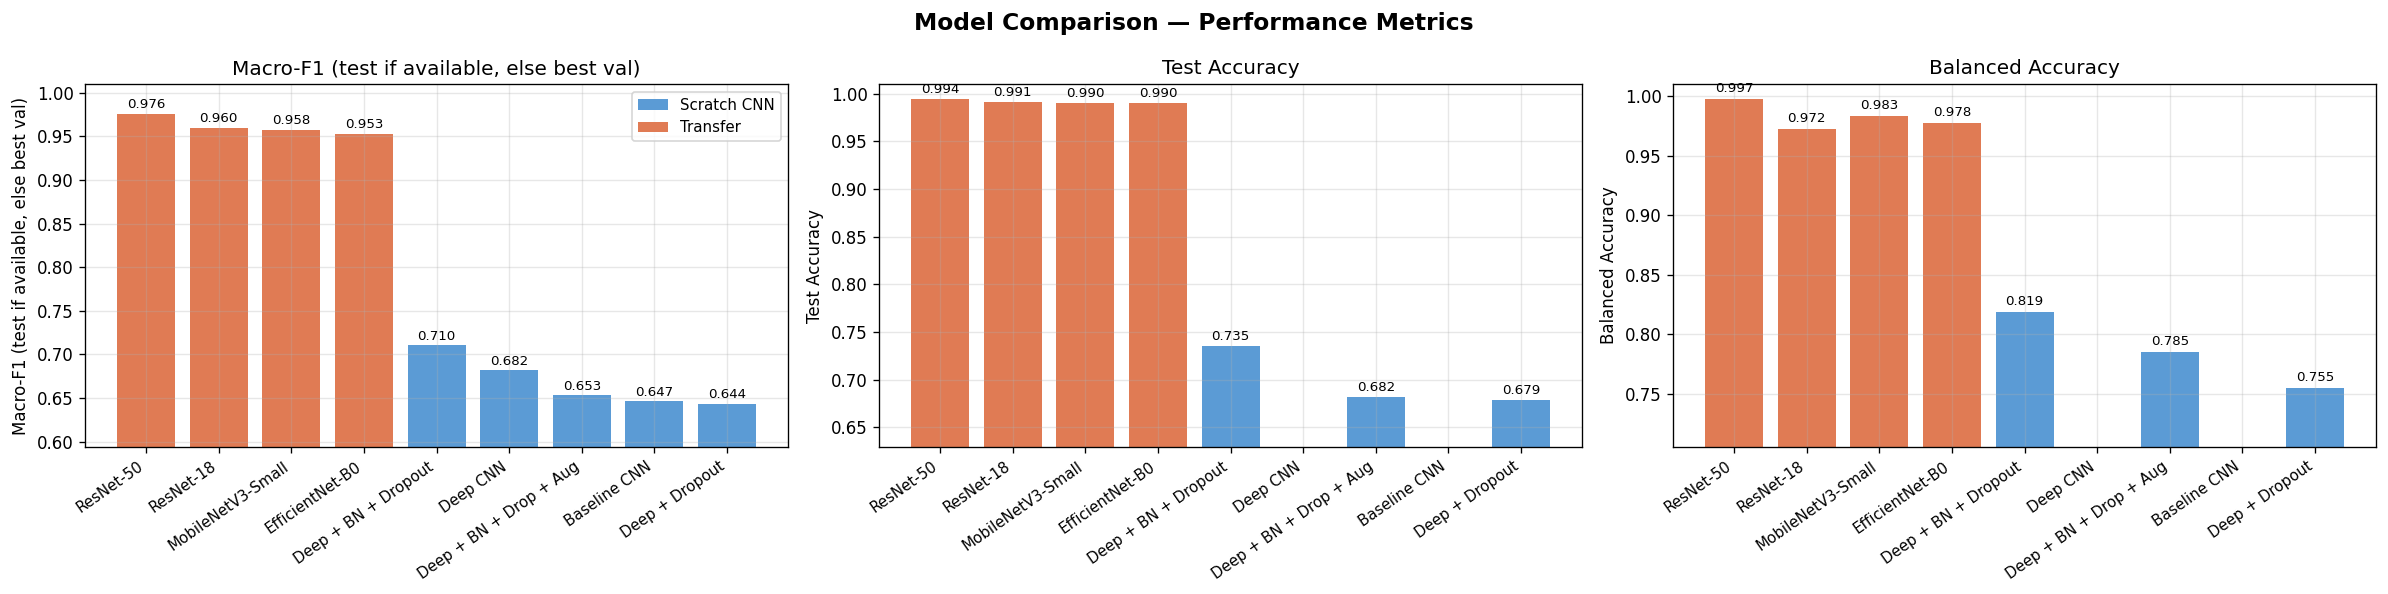

In [11]:
avail = df_sorted[df_sorted["Best F1"].notna() & (df_sorted["Best F1"] > 0)].copy()
names = avail["Model"].tolist()
colors = ["#e07b54" if t == "Transfer" else "#5b9bd5" for t in avail["Type"]]
x = np.arange(len(names))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Model Comparison — Performance Metrics", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [
    ("Best F1",  "Macro-F1 (test if available, else best val)"),
    ("Test Acc", "Test Accuracy"),
    ("Bal Acc",  "Balanced Accuracy"),
]):
    vals = avail[col].tolist()
    bars = ax.bar(x, vals, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(label)
    ymin = min(v for v in vals if not np.isnan(v))
    ax.set_ylim(max(0, ymin - 0.05), 1.01)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#5b9bd5", label="Scratch CNN"),
                   Patch(facecolor="#e07b54", label="Transfer")]
axes[0].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Training Curves - All Models Overview

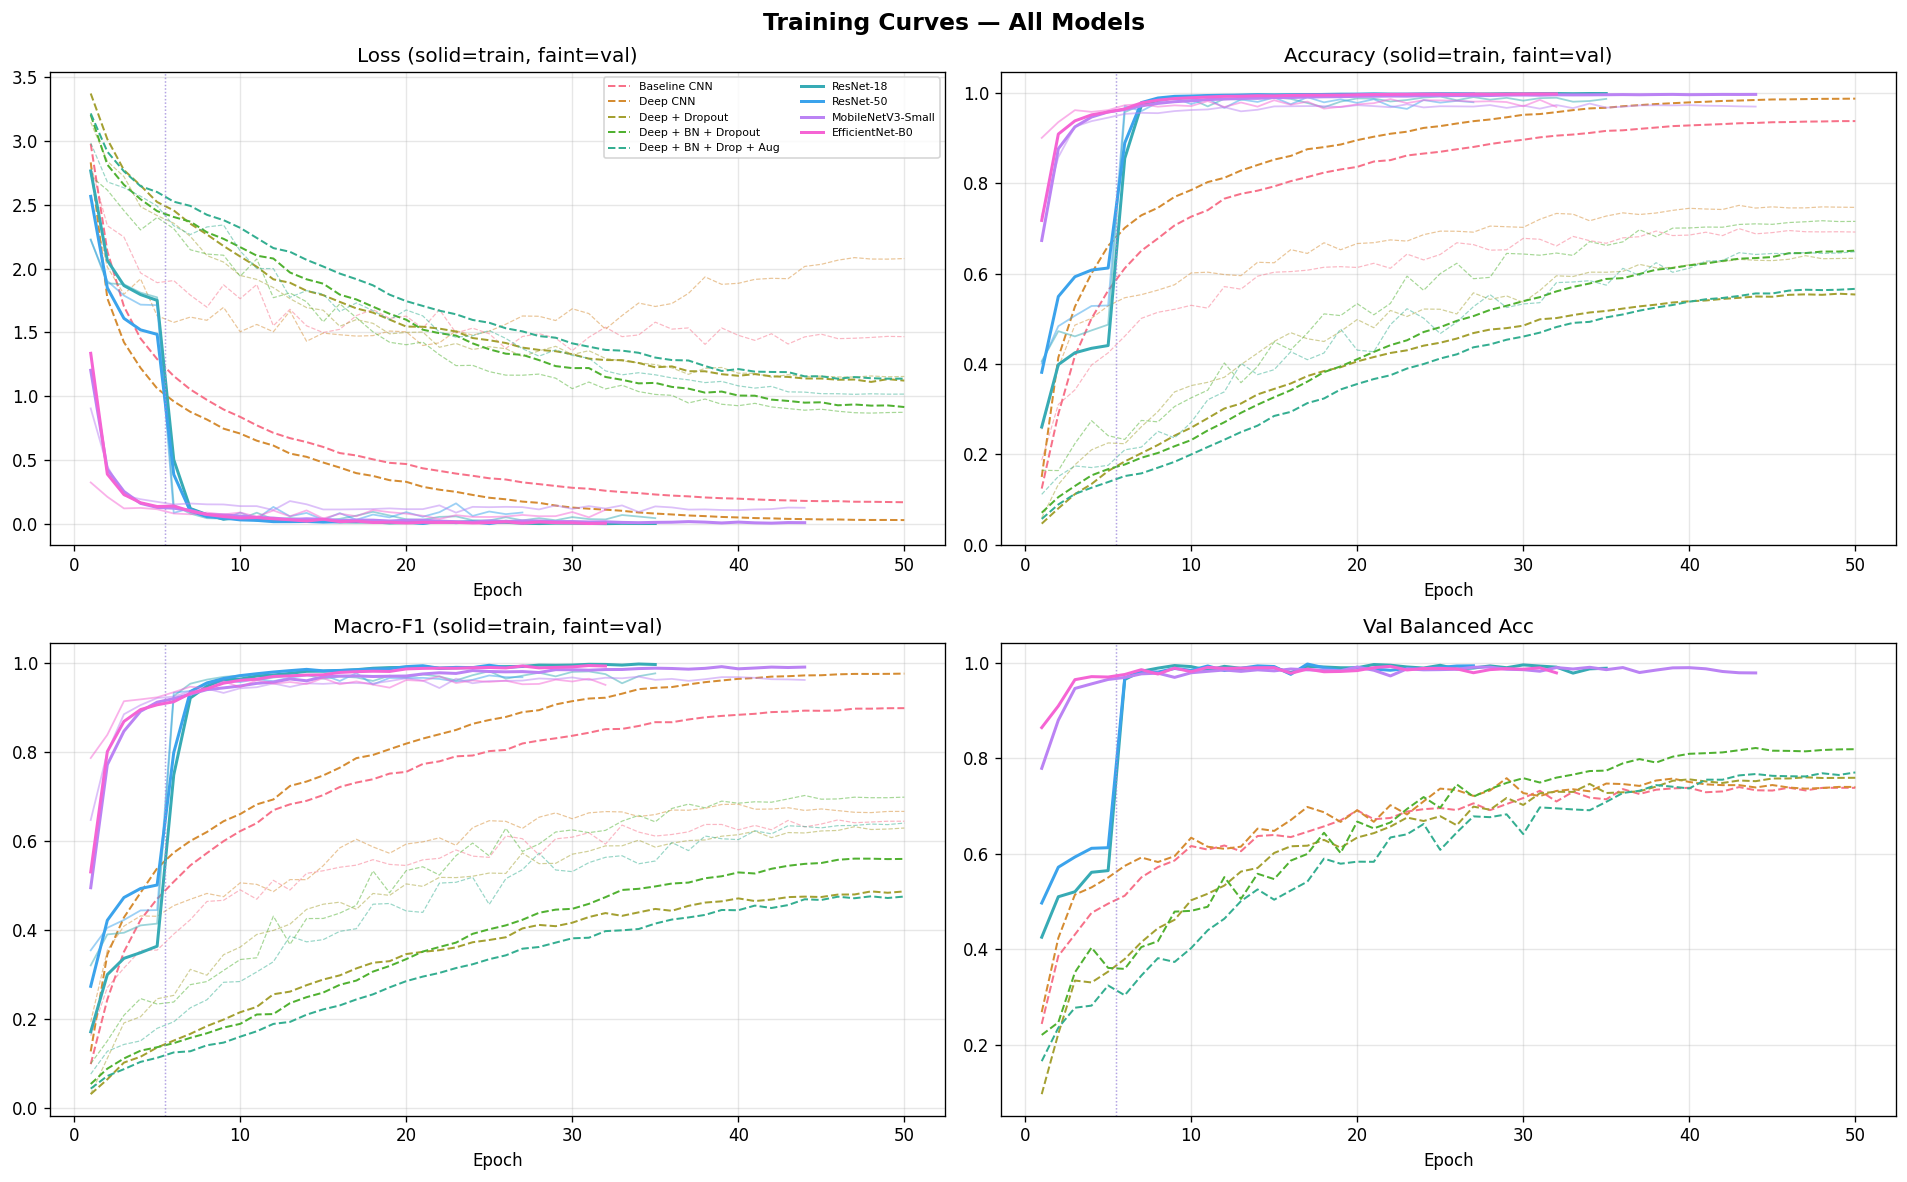

In [12]:
def combined_history(r):
    """Concatenate phase1 + phase2 histories. Returns (dict, phase_boundary_epoch)."""
    h1 = r.get("phase1_history") or {}
    h2 = r.get("history") or {}
    if not h2:
        return None, 0
    if not h1:
        return h2, 0
    boundary = len(h1.get("train_loss", []))
    combined = {k: list(h1.get(k, [])) + list(h2.get(k, [])) for k in h2}
    return combined, boundary


scratch_results  = [r for r in available if not r["is_transfer"]]
transfer_results = [r for r in available if r["is_transfer"]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")

metric_cfg = [
    ("train_loss",     "val_loss",     "Loss"),
    ("train_acc",      "val_acc",      "Accuracy"),
    ("train_macro_f1", "val_macro_f1", "Macro-F1"),
    ("val_balanced_acc", None,         "Val Balanced Acc"),
]

palette = sns.color_palette("husl", len(available))

for ax, (m_train, m_val, title) in zip(axes.flatten(), metric_cfg):
    for r, color in zip(available, palette):
        hist, boundary = combined_history(r)
        if hist is None or m_train not in hist:
            continue
        epochs = list(range(1, len(hist[m_train]) + 1))
        lw = 1.8 if r["is_transfer"] else 1.2
        ls = "-" if r["is_transfer"] else "--"
        ax.plot(epochs, hist[m_train], color=color, linewidth=lw, linestyle=ls,
                label=r["display_name"])
        if m_val and m_val in hist:
            ax.plot(epochs, hist[m_val], color=color, linewidth=lw * 0.6,
                    linestyle=ls, alpha=0.5)
        if boundary > 0:
            ax.axvline(boundary + 0.5, color=color, linestyle=":", alpha=0.3, linewidth=0.8)
    ax.set_title(title + (" (solid=train, faint=val)" if m_val else ""))
    ax.set_xlabel("Epoch")

axes[0, 0].legend(fontsize=6.5, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_training_curves_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Training Curves - Per Model

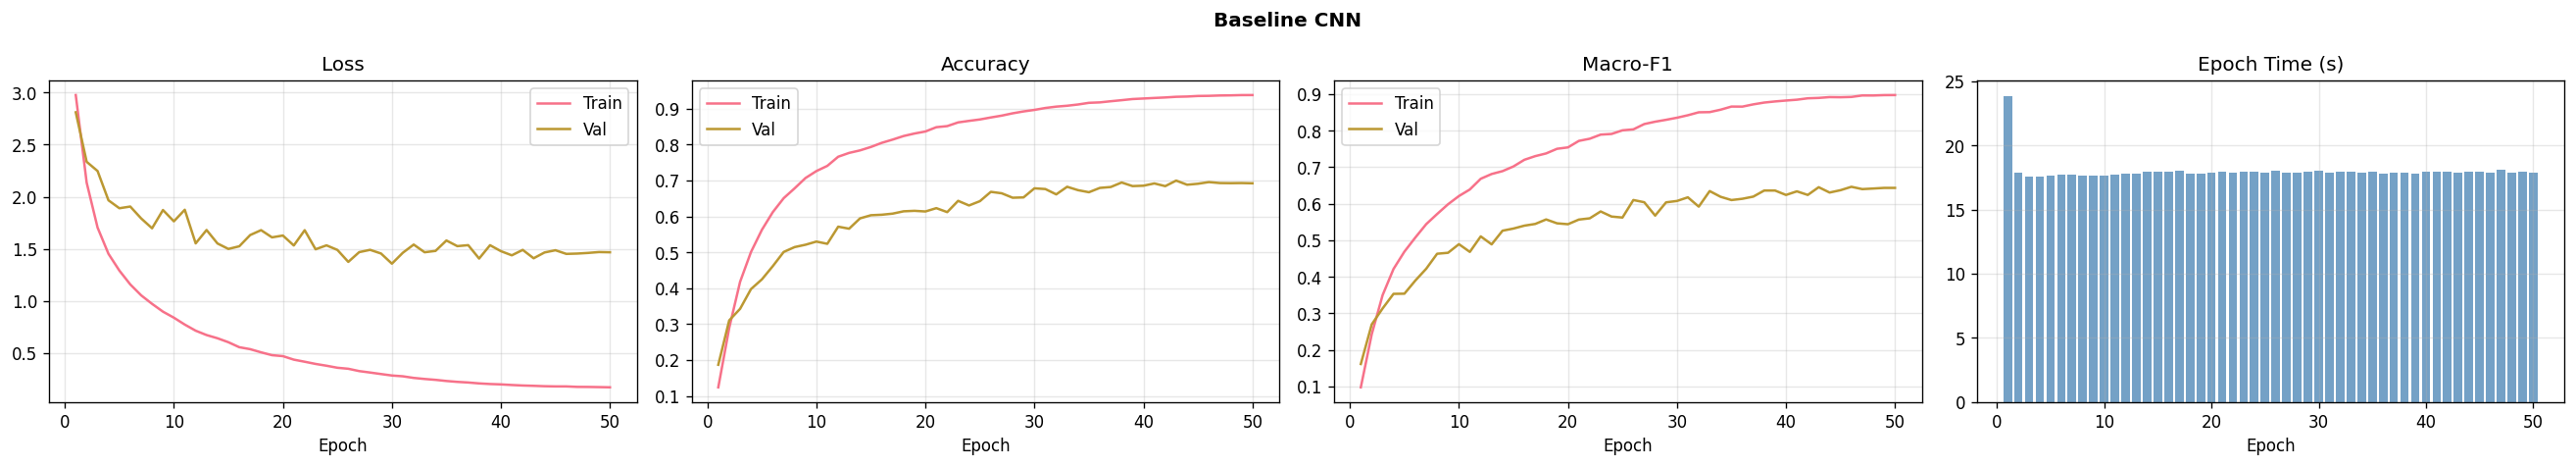

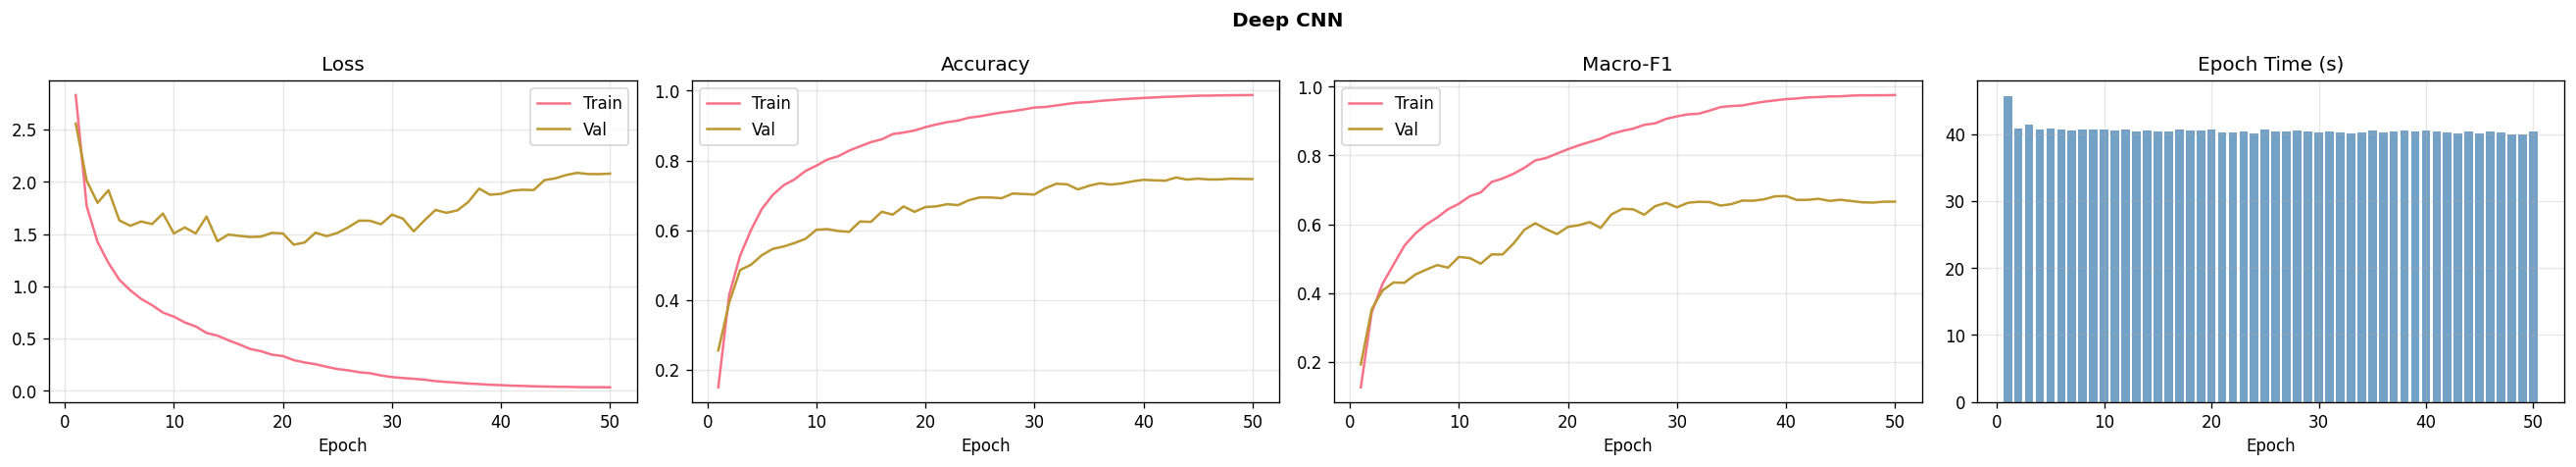

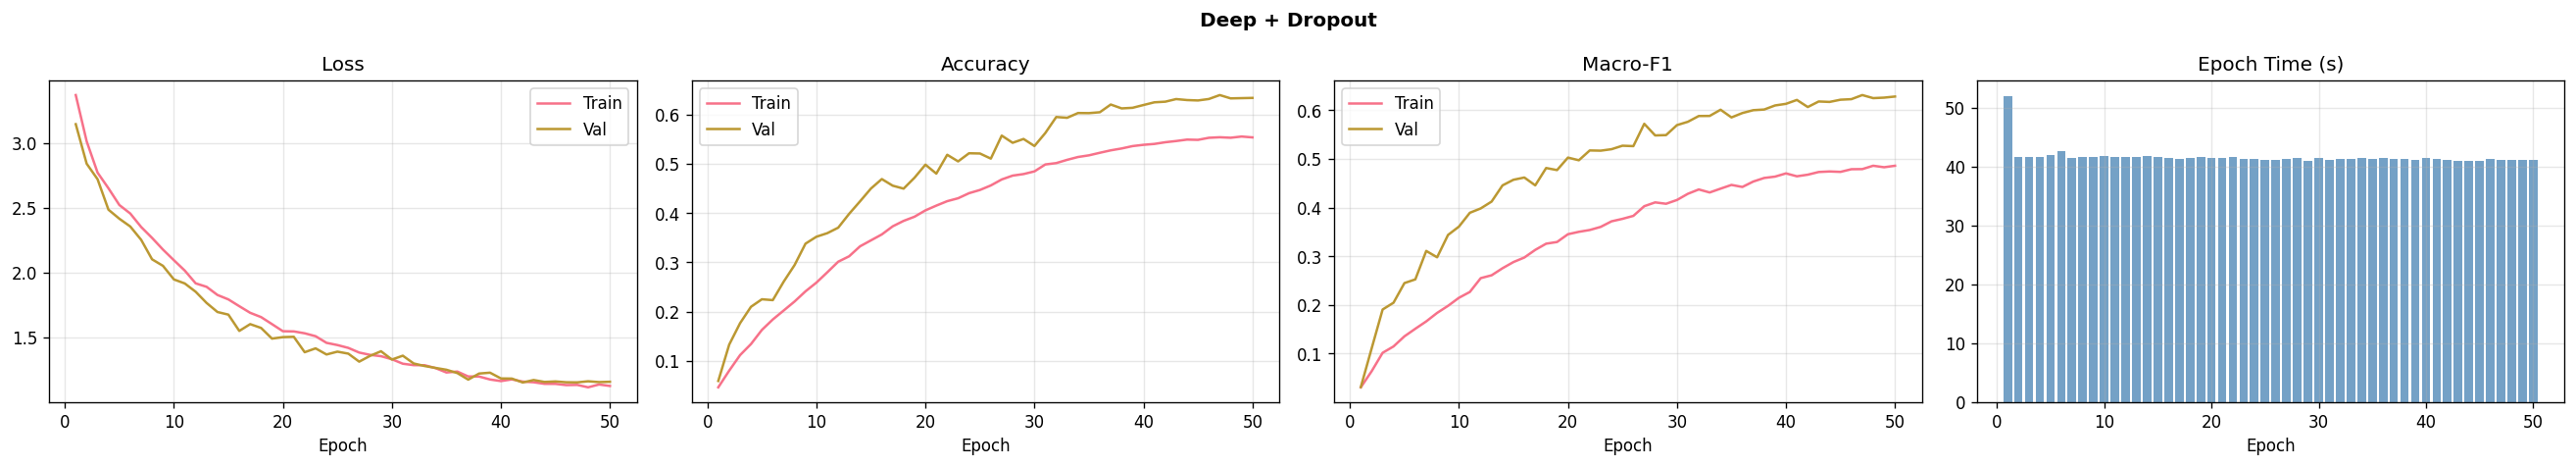

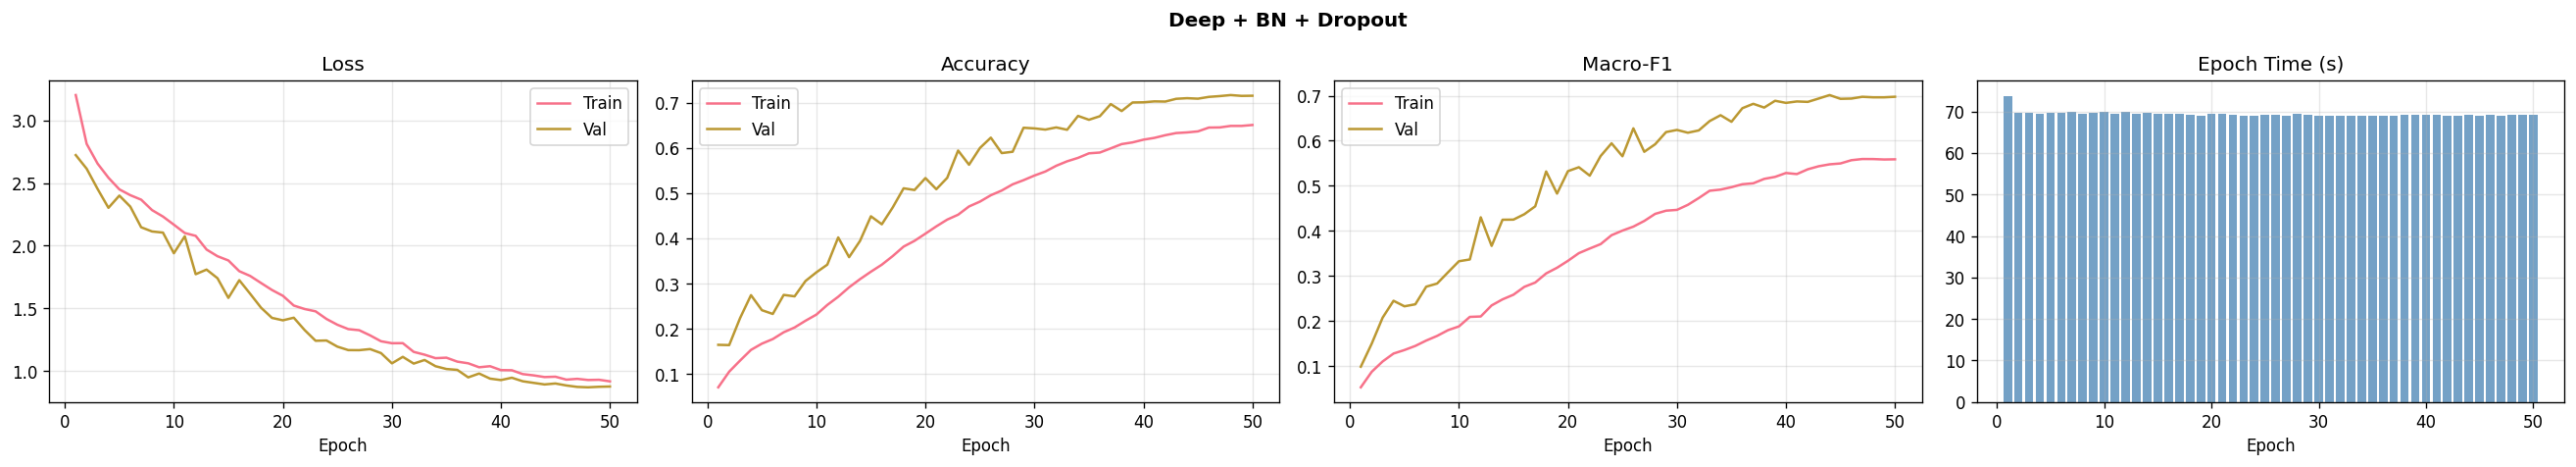

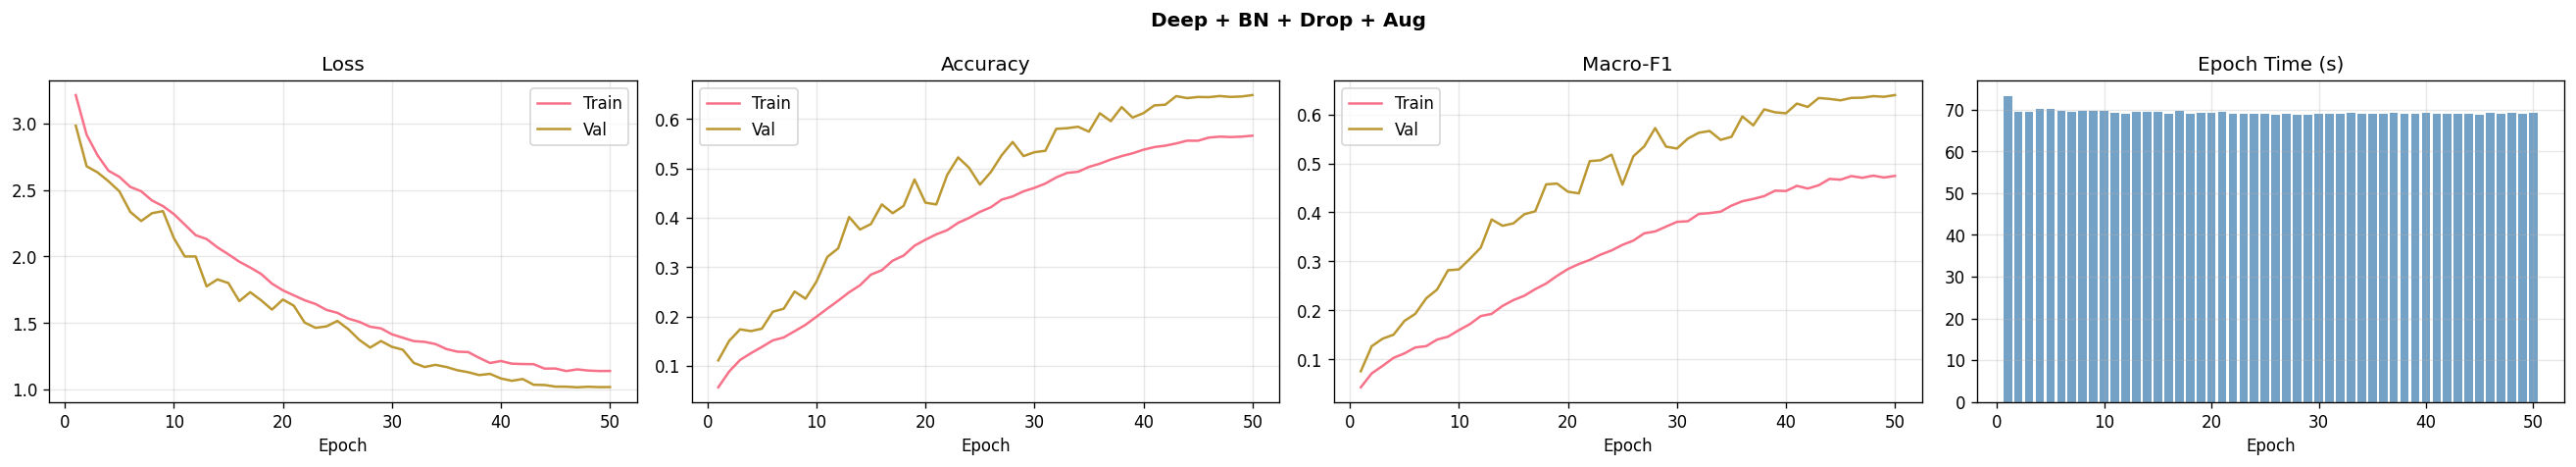

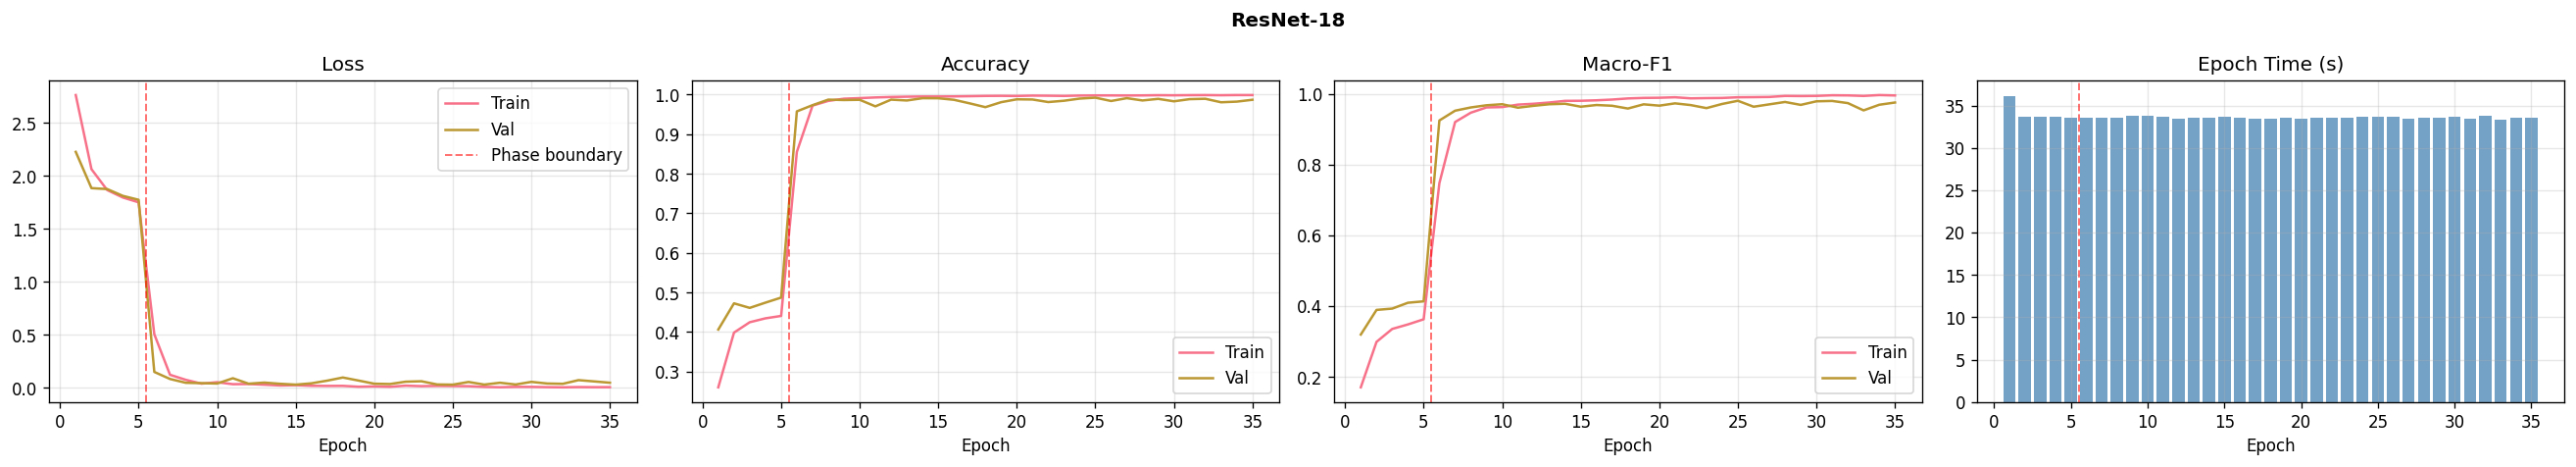

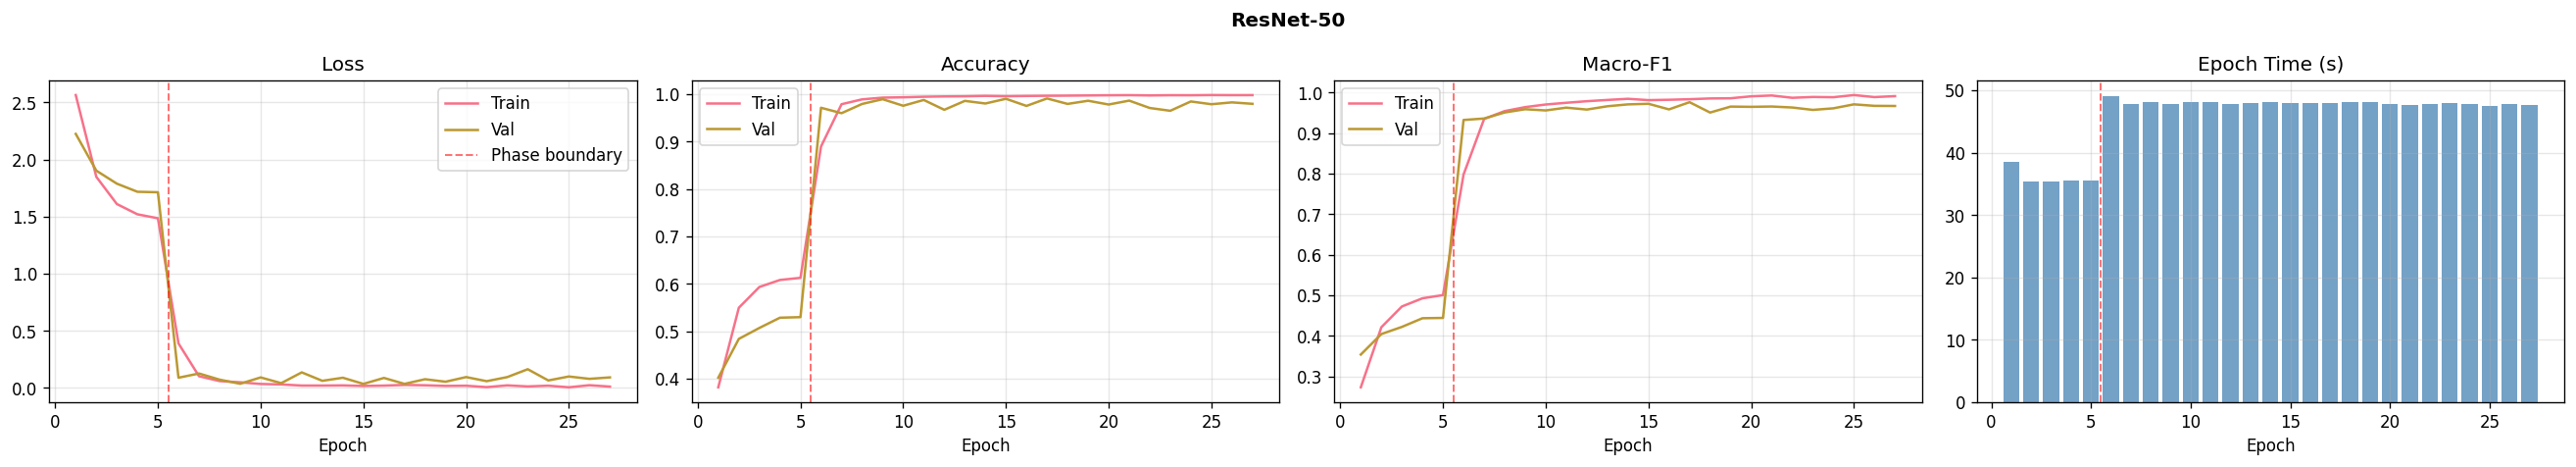

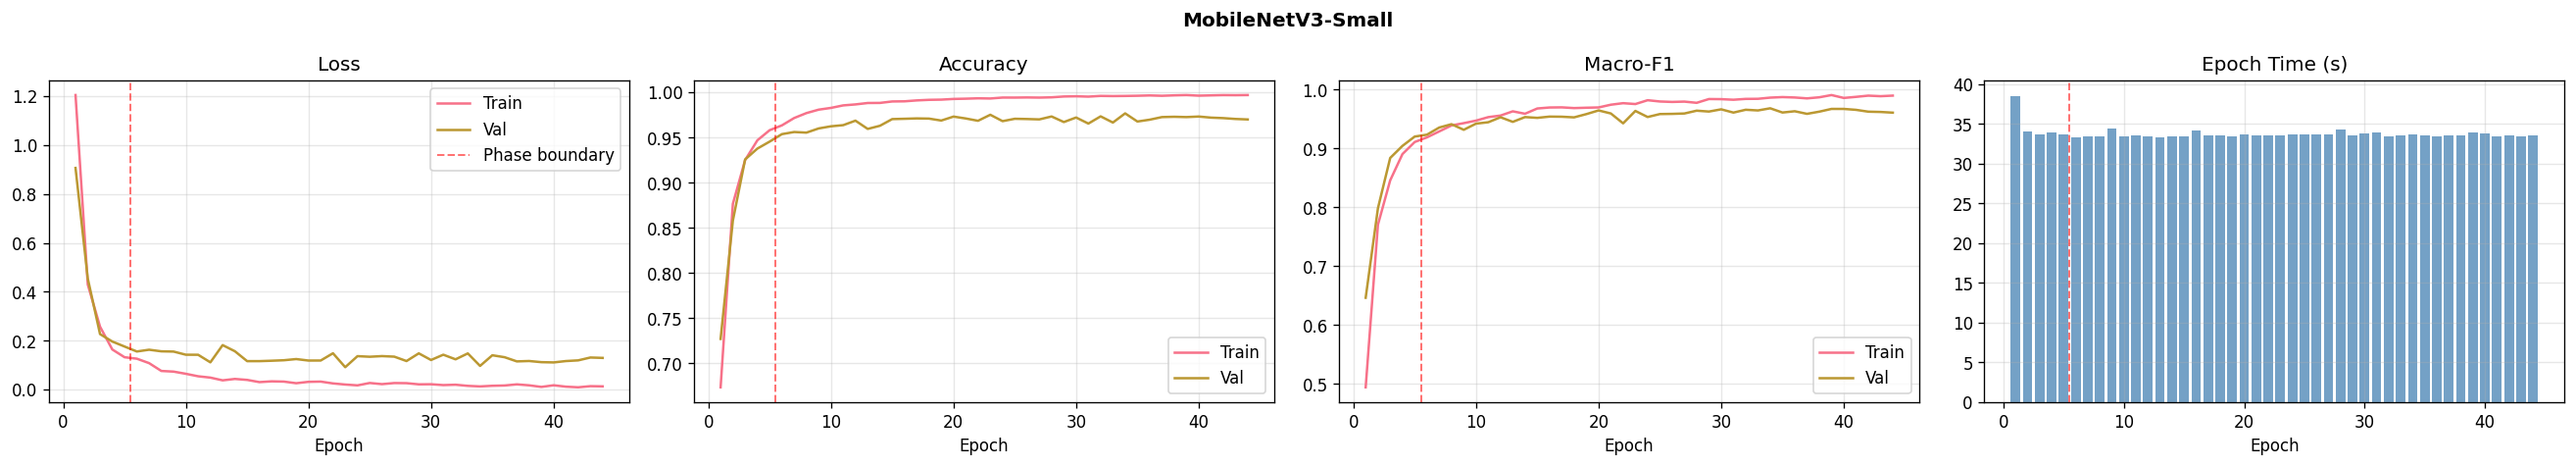

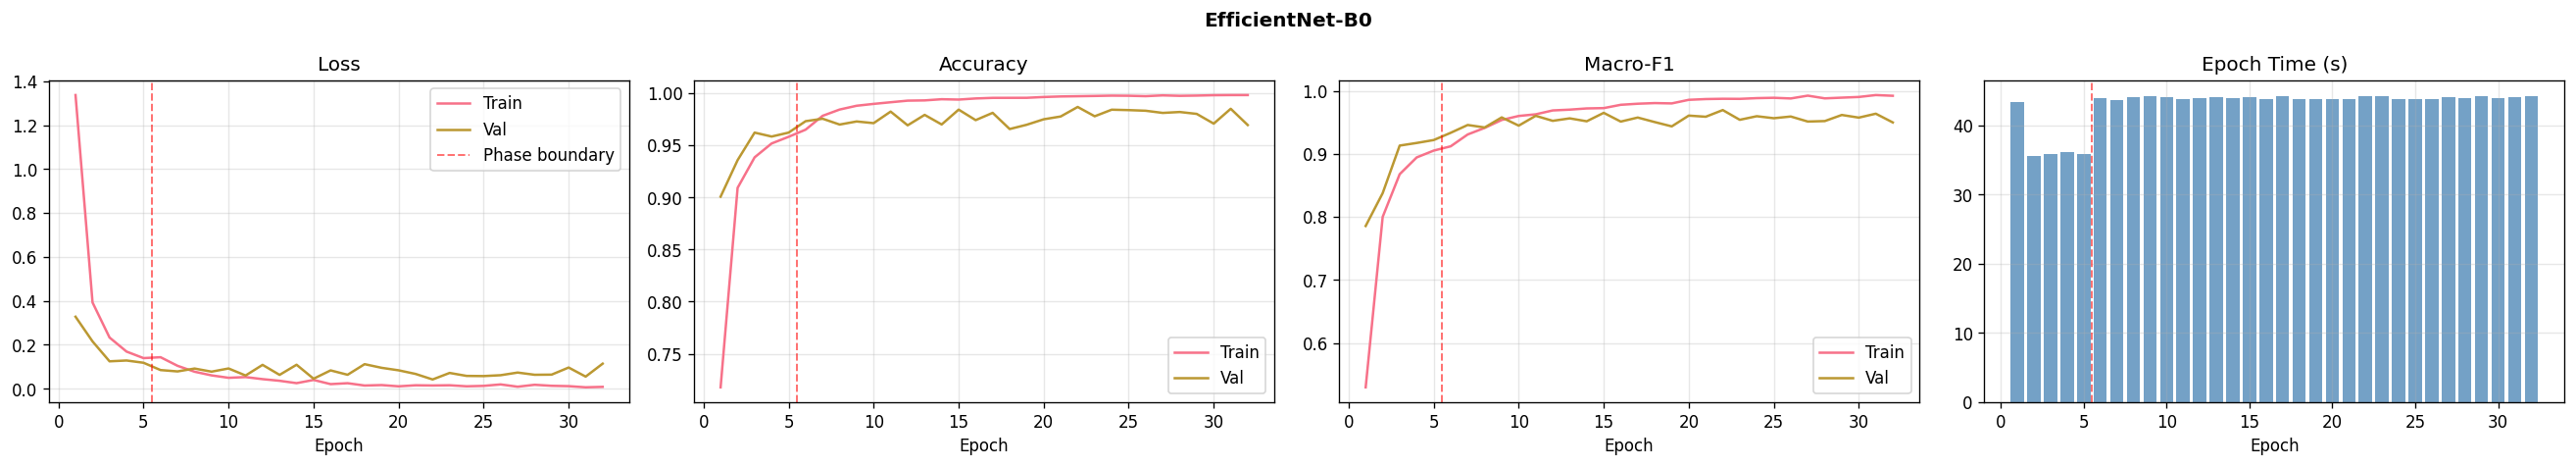

In [13]:
for r in available:
    hist, boundary = combined_history(r)
    if hist is None:
        print(f"  No history for {r['display_name']}")
        continue

    epochs = list(range(1, len(hist["train_loss"]) + 1))
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"{r['display_name']}", fontsize=12, fontweight="bold")

    # Loss
    axes[0].plot(epochs, hist["train_loss"], label="Train")
    axes[0].plot(epochs, hist["val_loss"],   label="Val")
    axes[0].set(title="Loss", xlabel="Epoch")
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, hist["train_acc"], label="Train")
    axes[1].plot(epochs, hist["val_acc"],   label="Val")
    axes[1].set(title="Accuracy", xlabel="Epoch")
    axes[1].legend()

    # Macro-F1
    if "val_macro_f1" in hist:
        axes[2].plot(epochs, hist.get("train_macro_f1", [float("nan")] * len(epochs)), label="Train")
        axes[2].plot(epochs, hist["val_macro_f1"], label="Val")
        axes[2].set(title="Macro-F1", xlabel="Epoch")
        axes[2].legend()

    # Epoch time
    if "epoch_time_s" in hist:
        axes[3].bar(epochs, hist["epoch_time_s"], color="steelblue", alpha=0.75)
        axes[3].set(title="Epoch Time (s)", xlabel="Epoch")

    # Phase boundary (transfer models)
    if boundary > 0:
        for ax in axes:
            ax.axvline(boundary + 0.5, color="red", linestyle="--",
                       alpha=0.55, linewidth=1.2, label="Phase boundary")
        axes[0].legend()

    plt.tight_layout()
    safe = r["exp_dir"].replace("/", "_")
    plt.savefig(FIGURES_DIR / f"03_curves_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Confusion Matrices

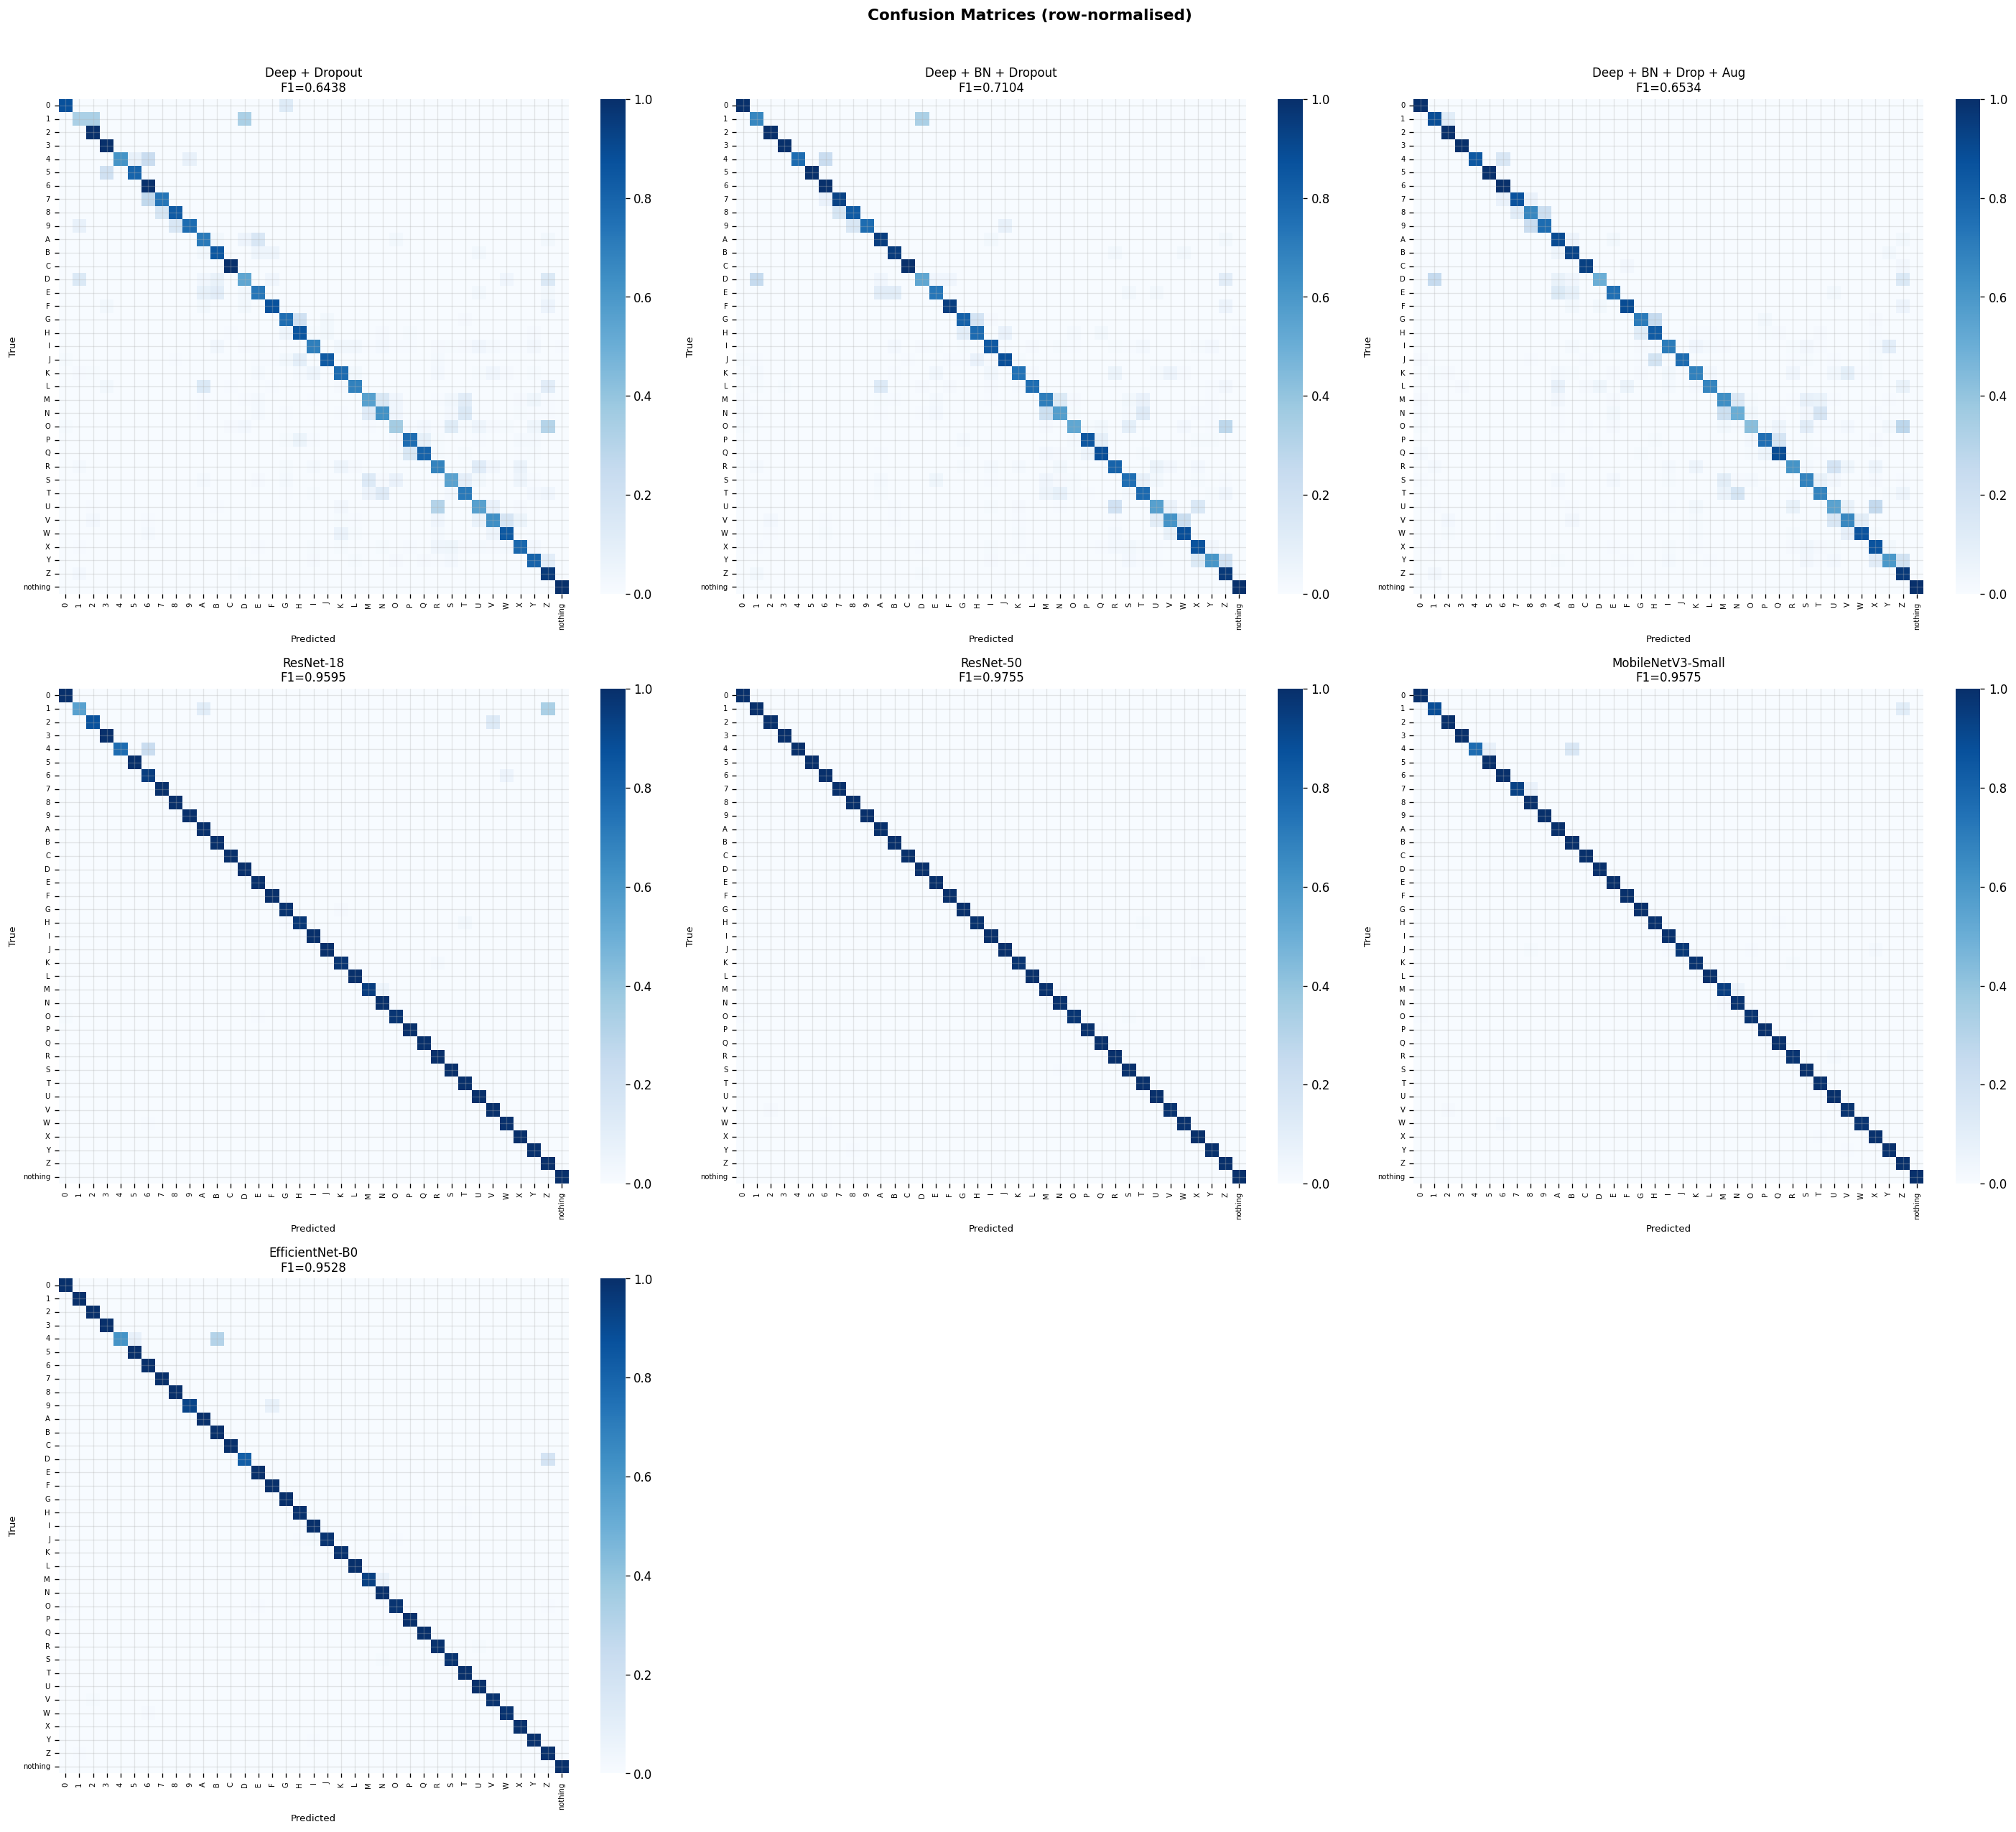


Displaying saved confusion-matrix images (from notebooks):


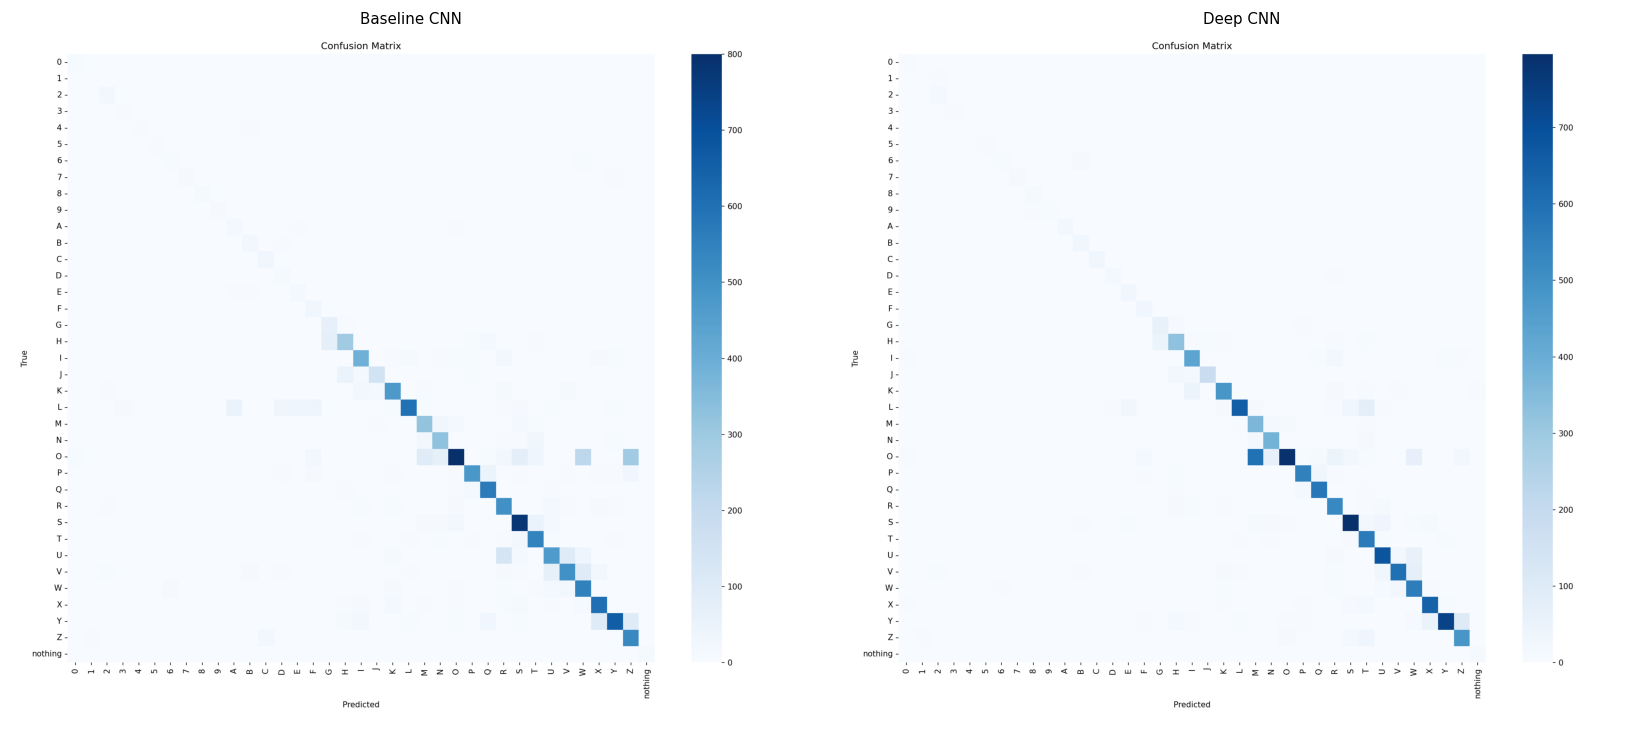

In [14]:
cm_ready = [r for r in available if r.get("y_true") is not None]
cm_img   = [r for r in available if r.get("cm_path") and r.get("y_true") is None]

# -- Replot from raw predictions (rich: normalised + per-class %) --
if cm_ready:
    n = len(cm_ready)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 8, nrows * 7))
    axes_flat = np.array(axes).flatten()

    for i, r in enumerate(cm_ready):
        cm = confusion_matrix(r["y_true"], r["y_pred"])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ax = axes_flat[i]
        sns.heatmap(cm_norm, annot=False, fmt=".2f", cmap="Blues",
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                    vmin=0, vmax=1)
        f1 = r.get("test_results", {}) or {}
        f1_str = f"F1={f1.get('test_macro_f1', best_val_f1(r)):.4f}"
        ax.set_title(f"{r['display_name']}\n{f1_str}", fontsize=10)
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True", fontsize=8)
        ax.tick_params(axis="both", labelsize=6)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle("Confusion Matrices (row-normalised)", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()

# -- Fall back: display saved cm.png images --
if cm_img:
    print("\nDisplaying saved confusion-matrix images (from notebooks):")
    n = len(cm_img)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6))
    axes_flat = np.array(axes).flatten()
    for i, r in enumerate(cm_img):
        img = mpimg.imread(r["cm_path"])
        axes_flat[i].imshow(img)
        axes_flat[i].set_title(r["display_name"], fontsize=9)
        axes_flat[i].axis("off")
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_confusion_matrices_notebook.png", dpi=150, bbox_inches="tight")
    plt.show()

## Per-Class F1 Heatmap

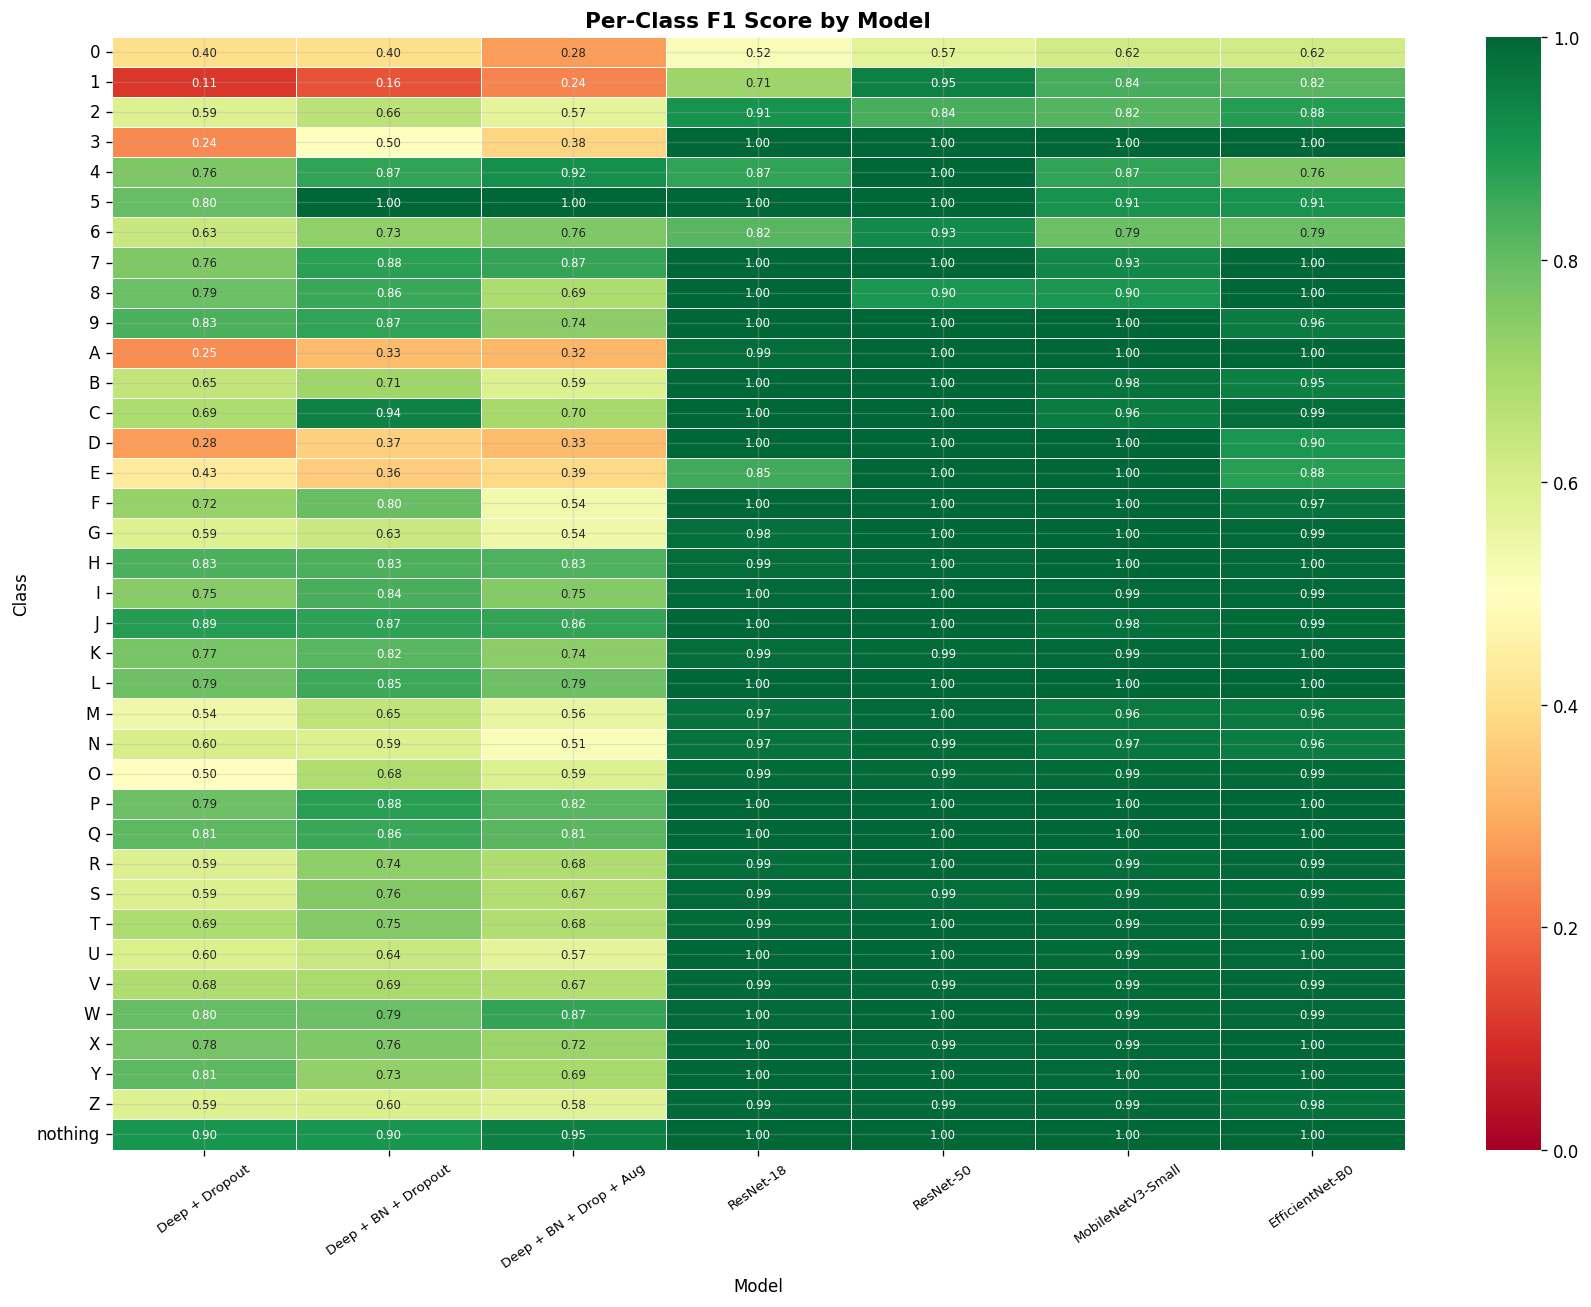

In [15]:
per_class = {}
for r in available:
    if r.get("y_true") is not None:
        f1s = f1_score(r["y_true"], r["y_pred"], average=None, zero_division=0)
        per_class[r["display_name"]] = f1s

if per_class:
    df_f1 = pd.DataFrame(per_class, index=CLASSES)
    fig, ax = plt.subplots(figsize=(len(per_class) * 1.8 + 2, 11))
    sns.heatmap(df_f1, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0, vmax=1, ax=ax, linewidths=0.4, annot_kws={"size": 7})
    ax.set_title("Per-Class F1 Score by Model", fontsize=13, fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Class")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_per_class_f1.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Per-class F1 heatmap requires y_true/y_pred.npy — only available for SLURM-trained models.")

## Classification Reports

In [16]:
for r in available:
    if r.get("y_true") is None:
        continue
    print(f"\n{'='*64}")
    print(f"  {r['display_name'].upper()}")
    print(f"{'='*64}")
    print(classification_report(
        r["y_true"], r["y_pred"],
        target_names=CLASSES,
        zero_division=0,
    ))


  DEEP + DROPOUT
              precision    recall  f1-score   support

           0       0.26      0.88      0.40         8
           1       0.07      0.33      0.11         9
           2       0.42      1.00      0.59        23
           3       0.14      1.00      0.24         4
           4       1.00      0.62      0.76        13
           5       0.80      0.80      0.80         5
           6       0.46      1.00      0.63        19
           7       0.79      0.73      0.76        15
           8       0.75      0.83      0.79        18
           9       0.91      0.77      0.83        13
           A       0.15      0.72      0.25        39
           B       0.52      0.85      0.65        40
           C       0.52      1.00      0.69        34
           D       0.19      0.54      0.28        28
           E       0.31      0.73      0.43        37
           F       0.62      0.87      0.72        39
           G       0.48      0.76      0.59        84
         

## Training Time Analysis

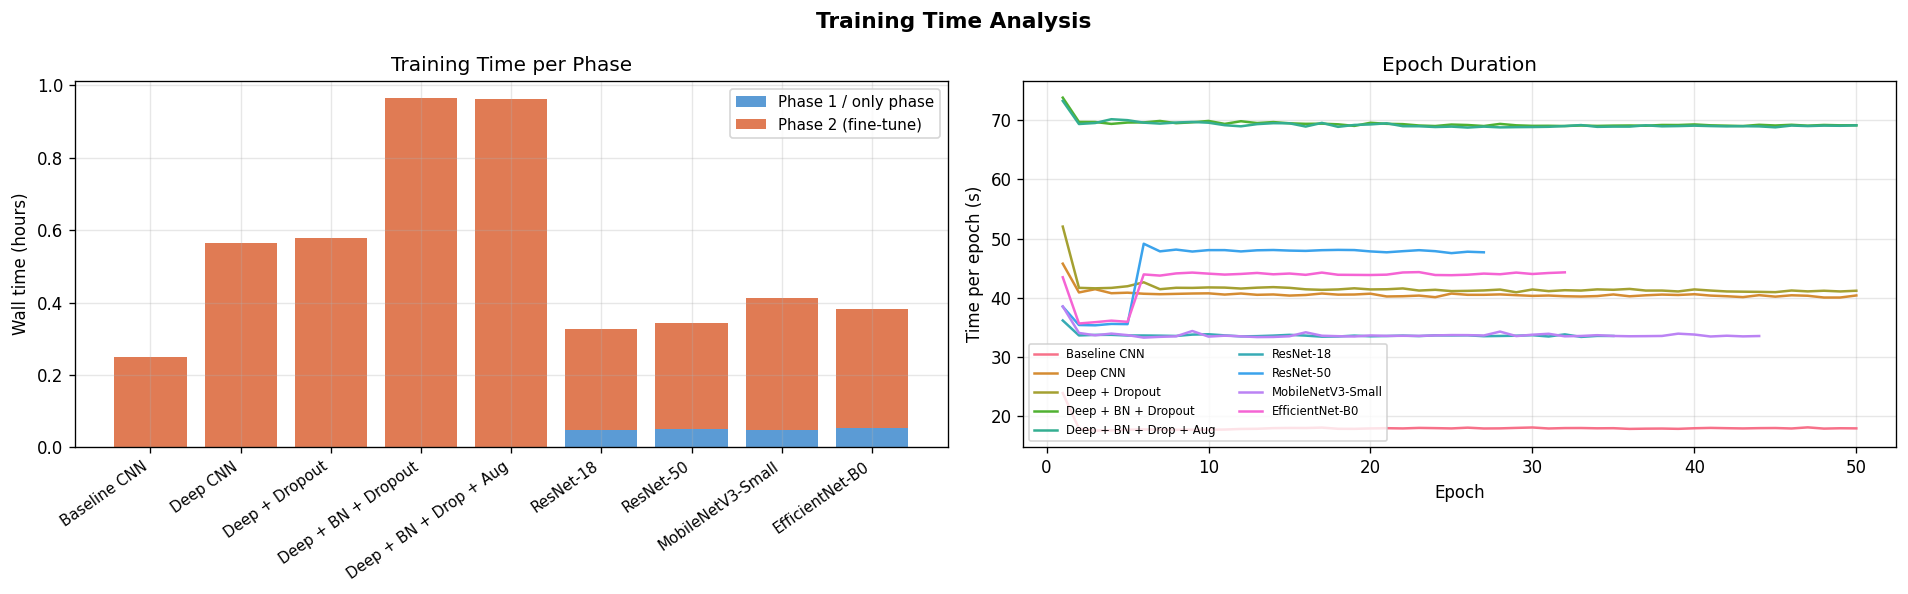

In [17]:
timing_rows = []
for r in available:
    h1 = r.get("phase1_history") or {}
    h2 = r.get("history") or {}
    t1 = sum(h1.get("epoch_time_s", [])) / 3600
    t2 = sum(h2.get("epoch_time_s", [])) / 3600
    timing_rows.append({
        "model": r["display_name"],
        "phase1_h": t1,
        "phase2_h": t2,
        "total_h":  t1 + t2,
        "is_transfer": r["is_transfer"],
    })

df_time = pd.DataFrame(timing_rows)
x = np.arange(len(df_time))
colors_t = ["#e07b54" if t else "#5b9bd5" for t in df_time["is_transfer"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Time Analysis", fontsize=13, fontweight="bold")

# Stacked bar: phase1 + phase2
axes[0].bar(x, df_time["phase1_h"], label="Phase 1 / only phase", color="#5b9bd5")
axes[0].bar(x, df_time["phase2_h"], bottom=df_time["phase1_h"],
            label="Phase 2 (fine-tune)", color="#e07b54")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_time["model"], rotation=35, ha="right", fontsize=9)
axes[0].set_ylabel("Wall time (hours)")
axes[0].set_title("Training Time per Phase")
axes[0].legend(fontsize=9)

# Epoch time distribution
for r, color in zip(available, sns.color_palette("husl", len(available))):
    hist, _ = combined_history(r)
    if hist and "epoch_time_s" in hist:
        epochs = list(range(1, len(hist["epoch_time_s"]) + 1))
        axes[1].plot(epochs, hist["epoch_time_s"], color=color,
                     linewidth=1.5, label=r["display_name"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Time per epoch (s)")
axes[1].set_title("Epoch Duration")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_training_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Tradeoff Analysis
Scatter plots to visualise the accuracy / complexity / speed tradeoff.

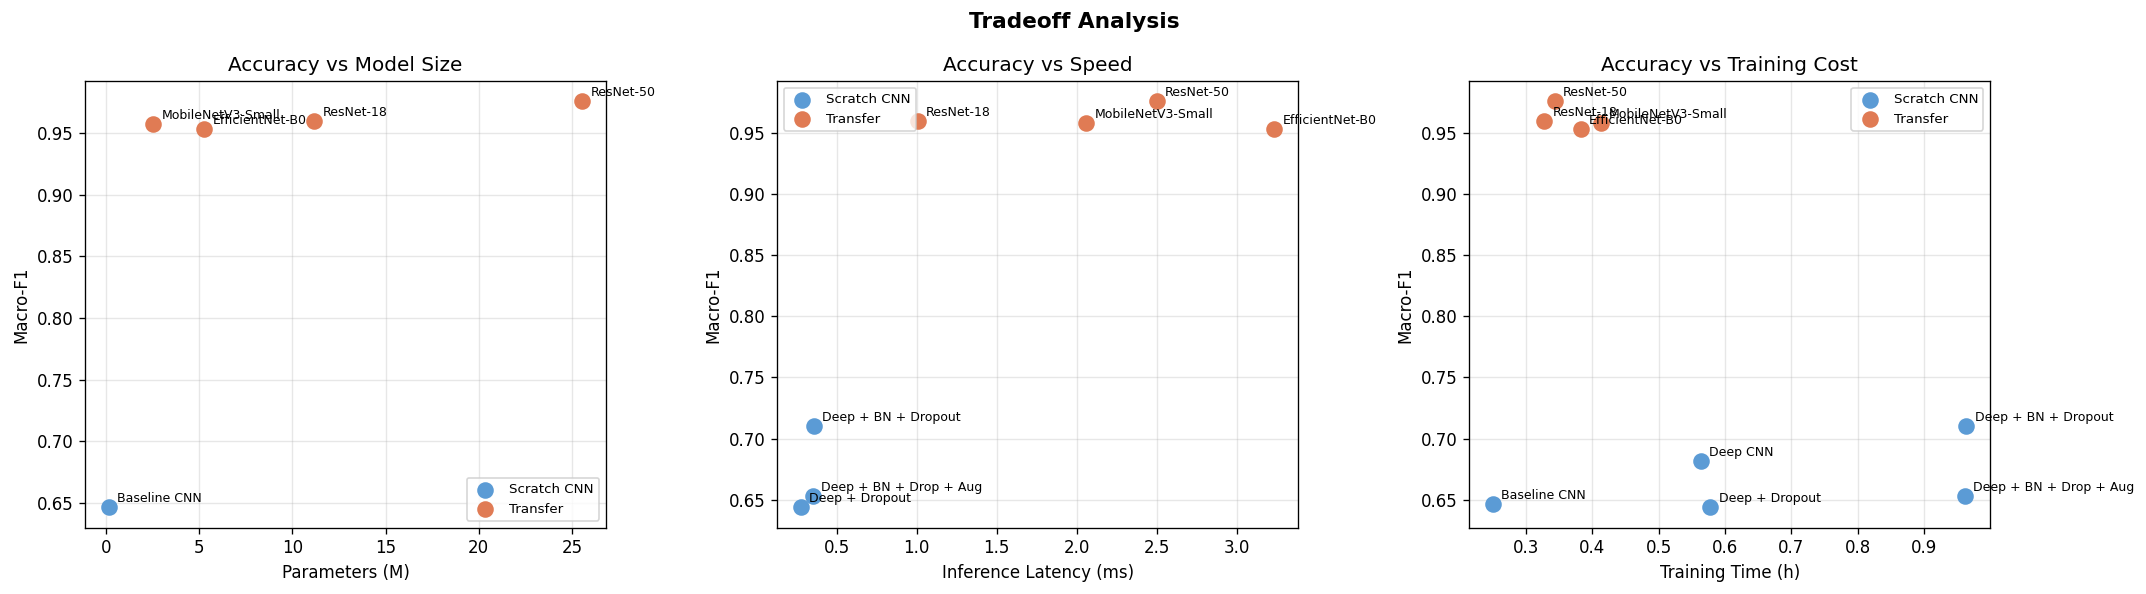

In [18]:
df_trade = df_sorted.copy()
df_trade = df_trade[df_trade["Best F1"].notna() & (df_trade["Best F1"] > 0)]

has_params   = df_trade["Params (M)"].notna().any()
has_latency  = df_trade["Latency (ms)"].notna().any()
has_time     = df_trade["Train Time (h)"].notna().any()

ncols = sum([has_params, has_latency, has_time])
if ncols == 0:
    print("Not enough data for tradeoff scatter plots.")
else:
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 6, 5))
    if ncols == 1:
        axes = [axes]
    fig.suptitle("Tradeoff Analysis", fontsize=13, fontweight="bold")

    ax_idx = 0
    mtype_colors = {"Scratch CNN": "#5b9bd5", "Transfer": "#e07b54"}

    def scatter_plot(ax, x_col, y_col, xlabel, ylabel, title):
        sub = df_trade[["Model", "Type", x_col, y_col]].dropna()
        for mtype, grp in sub.groupby("Type"):
            ax.scatter(grp[x_col], grp[y_col],
                       c=mtype_colors.get(mtype, "grey"),
                       label=mtype, s=80, zorder=3)
            for _, row in grp.iterrows():
                ax.annotate(row["Model"], (row[x_col], row[y_col]),
                            textcoords="offset points", xytext=(5, 3),
                            fontsize=7.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)

    if has_params:
        scatter_plot(axes[ax_idx], "Params (M)", "Best F1",
                     "Parameters (M)", "Macro-F1", "Accuracy vs Model Size")
        ax_idx += 1
    if has_latency:
        scatter_plot(axes[ax_idx], "Latency (ms)", "Best F1",
                     "Inference Latency (ms)", "Macro-F1", "Accuracy vs Speed")
        ax_idx += 1
    if has_time:
        scatter_plot(axes[ax_idx], "Train Time (h)", "Best F1",
                     "Training Time (h)", "Macro-F1", "Accuracy vs Training Cost")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "07_tradeoff.png", dpi=150, bbox_inches="tight")
    plt.show()

## Final Ranking

In [19]:
print("\n=== MODEL RANKING (by Macro-F1) ===\n")
print(f"{'#':<4} {'Model':<30} {'Type':<14} {'F1':>7} {'Acc':>7} "
      f"{'Bal Acc':>8} {'Latency':>10} {'Params':>8} {'Train':>8}")
print("-" * 100)

for rank, (_, row) in enumerate(df_sorted.iterrows(), 1):
    f1  = fmt(row["Best F1"],       "{:.4f}")
    acc = fmt(row["Test Acc"],       "{:.4f}")
    bal = fmt(row["Bal Acc"],        "{:.4f}")
    lat = fmt(row["Latency (ms)"],   "{:.1f}ms")
    par = fmt(row["Params (M)"],     "{:.1f}M")
    tt  = fmt(row["Train Time (h)"], "{:.1f}h")
    print(f"{rank:<4} {row['Model']:<30} {row['Type']:<14} "
          f"{f1:>7} {acc:>7} {bal:>8} {lat:>10} {par:>8} {tt:>8}")

print("\nNote: F1 = Test Macro-F1 if test_results.json exists, otherwise best validation F1.")


=== MODEL RANKING (by Macro-F1) ===

#    Model                          Type                F1     Acc  Bal Acc    Latency   Params    Train
----------------------------------------------------------------------------------------------------
1    ResNet-50                      Transfer        0.9755  0.9939   0.9974      2.5ms    25.6M     0.3h
2    ResNet-18                      Transfer        0.9595  0.9914   0.9724      1.0ms    11.2M     0.3h
3    MobileNetV3-Small              Transfer        0.9575  0.9898   0.9831      2.1ms     2.5M     0.4h
4    EfficientNet-B0                Transfer        0.9528  0.9899   0.9776      3.2ms     5.3M     0.4h
5    Deep + BN + Dropout            Scratch CNN     0.7104  0.7352   0.8189      0.4ms        —     1.0h
6    Deep CNN                       Scratch CNN     0.6818       —        —          —        —     0.6h
7    Deep + BN + Drop + Aug         Scratch CNN     0.6534  0.6816   0.7855      0.4ms        —     1.0h
8    Baseline CNN    